## 00 Importar librerias

In [29]:
import pandas as pd   #analisis de datos
#import missingno as msno  #visualiza datos nulos
from sklearn.model_selection import train_test_split   #nos permite dividir un dataset en dos bloques, típicamente bloques destinados al entrenamiento y validación del modelo
import matplotlib.pyplot as plt   #visualizar datos, hacer graficos
import seaborn as sns  # graficos
import numpy as np  #calculos numericos


## 01 Adjuntar Archivo - Recopilar datos

In [30]:
airbnb= "https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv"
data = pd.read_csv(airbnb)
total_data = (data).reset_index(inplace = False)
total_data.drop(columns = ["index"], inplace = True)
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 02 Exploracion y Limpieza

In [31]:
# Obtener las dimensiones
total_data.shape

(48895, 16)

In [32]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

* Existen un total de 48895 filas (propiedades para alquilar) y 16 columnas, de entre las que encontramos el objetivo a predecir, pudiera ser la variable *price*
* Las variables *last review y reviews_per_month* tienen 38843 instancias con valores, por lo que contendría más de 1000 valores nulos. 
* El resto de variables cuentan siempre con valor.
* Los datos cuentan con 10 características numéricas y 6 características categóricas.

In [33]:
# Eliminar duplicados 
total_data.drop("host_id", axis = 1).duplicated().sum()

#total_data = total_data.drop_duplicates()  #aplicar si encontramos duplicados.

np.int64(0)

In [34]:
total_data = total_data.drop_duplicates(subset = total_data.columns.difference(["host_id"]))
print(total_data.shape)
total_data.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [35]:
if total_data.duplicated().sum():
    total_data = total_data.drop_duplicates()
print(total_data.shape)
total_data.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### 2.1 Eliminar Informacion Irrelevante

* las variables *id y host_id* son solo números de identificación únicos, No aportan información sobre el precio o características del alojamiento. Son útiles para rastrear registros pero no para predecir.
* las variables *name y host_name* son texto libre, no tienen relacion con algo importante a predecir.
* la variable *last_review* es una fecha específica. Aunque podría indicar qué tan activo está el alojamiento.

### variables importantes:

#neighbourhood_group, neighbourhood: ubicación (¡muy importante!).
*latitude, longitude: coordenadas geográficas.
*room_type: tipo de habitación (entire home, private room, shared room).
*price: ¡tu variable objetivo!.
*minimum_nights: mínimo de noches.
*number_of_reviews: número de reseñas.
*reviews_per_month: frecuencia de reseñas.
*calculated_host_listings_count: cuántos alojamientos tiene el anfitrión.
*availability_365: días disponibles al año.


In [36]:
#eliminar
total_data = total_data.drop(["id", "host_id", "name", "host_name", "last_review"], axis = 1, inplace = False)
#total_data.drop(["id", "host_id", "name", "host_name", "last_review"], axis = 1, inplace = True)
total_data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [37]:
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


## 03 Análisis de variables univariante

Una variable univariante es un término estadístico que se emplea para referenciar un conjunto de observaciones de un atributo. Esto es, el análisis columna a columna del DataFrame. Para ello, debemos distinguir si una variable es categórica o numérica, ya que el cuerpo del análisis y las conclusiones que se pueden obtener serán distintas

### 3.1 Variable categórica

* neighbourhood_group.
* neighbourhood.
* room_type.

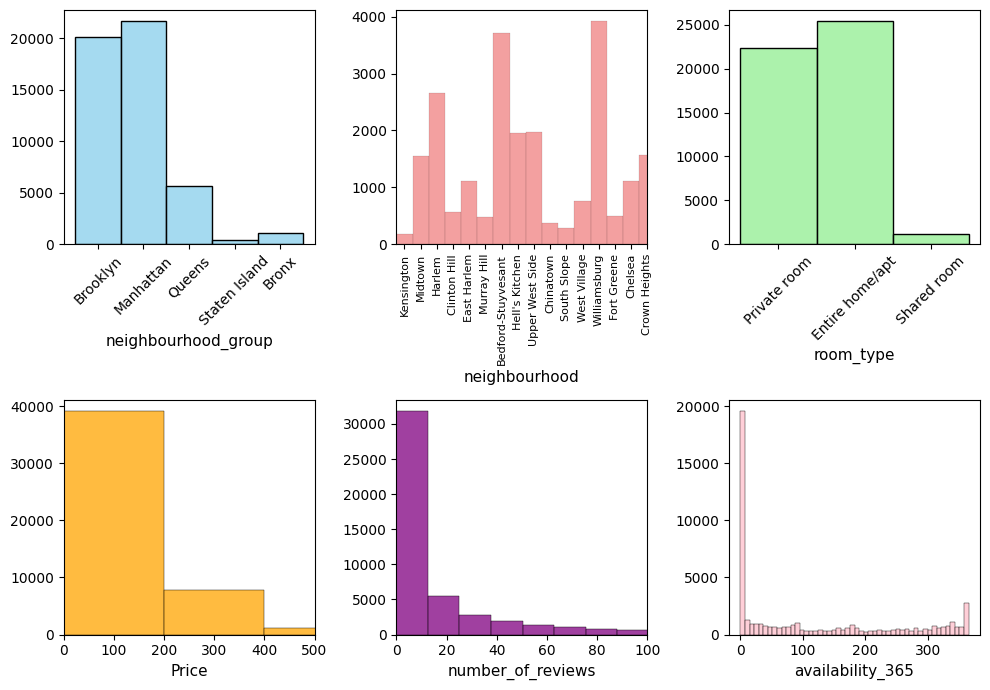

In [50]:
fig, axis = plt.subplots(2, 3, figsize = (10, 7))

# Crear un histograma múltiple
sns.histplot(ax=axis[0, 0], data=total_data, x="neighbourhood_group", color="skyblue").set(ylabel=None)
axis[0, 0].tick_params(axis='x', rotation=45, labelsize=10)
axis[0, 0].set_xlabel("neighbourhood_group", fontsize=11)

sns.histplot(ax=axis[0, 1], data=total_data, x="neighbourhood", color="lightcoral").set(ylabel=None)
axis[0, 1].tick_params(axis='x', rotation=90, labelsize=8)  # Rotación 90° porque hay muchos
axis[0, 1].set_xlabel("neighbourhood", fontsize=11)
axis[0, 1].set_xlim(-0.5, 15)  # Mostrar solo los primeros para legibilidad

sns.histplot(ax=axis[0, 2], data=total_data, x="room_type", color="lightgreen").set(ylabel=None)
axis[0, 2].tick_params(axis='x', rotation=45, labelsize=10)
axis[0, 2].set_xlabel("room_type", fontsize=11)

sns.histplot(ax=axis[1, 0], data=total_data, x="price", bins=50, color="orange").set(ylabel=None)
axis[1, 0].set_xlabel("Price", fontsize=11)
axis[1, 0].set_xlim(0, 500)  # Limitar outliers

sns.histplot(ax=axis[1, 1], data=total_data, x="number_of_reviews", bins=50, color="purple").set(ylabel=None)
axis[1, 1].set_xlabel("number_of_reviews", fontsize=11)
axis[1, 1].set_xlim(0, 100)  # Limitar outliers

sns.histplot(ax=axis[1, 2], data=total_data, x="availability_365", bins=50, color="pink").set(ylabel=None)
axis[1, 2].set_xlabel("availability_365", fontsize=11)
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Conclusiones
#### Neighbourhood_group :
Manhattan y Brooklyn son los que tienen mas alojamientos ya que son los que estan mas cerca de sitios turisticos, Queens tiene un nivel mas bajo y Bronx y Staten Island tienen muy pocos alojamientos.

#### Neighbourhood:
al reducir el numero de vecindarios a mostrar se puede observar que, Williamsburg, Bedford-Stuyvesant, Harlem están en el top de mayor alojamientos, siendo los otros vecindarios menos populares y con una distribución bastante desigual.

#### Room_type:


Entire home/apt,  es el tipo más común de alojamiento, Private room, es el segundo y Shared room es muy poco, la mayoria de los turistas prefieren privacidad.


#### Price: 

La mayoría de precios están entre $0 y $200, teniendo su mayoria entre $50 y $150 y algunos precios demasiado altos.

#### Number_of_reviews:

Los alojamientos tienen pocas reseñas y son pocos los que si tienen, puede ser a que los alojamientos pueden ser nuevos o simplemente no gustaron y no dejaron reseña

#### Availability_365:

Hay gran cantidad de alojamientos en el dato 0, lo que nos puede dar a entender que estan disponibles esporadicamente y los que estan disponibles todo el año puede ser por que son profesionales dedicados a este negocio.






### 3.2 Variable numérica

* price
* latitude y longitude 
* minimum_nights 
* number_of_reviews 
* calculated_host_listings_count



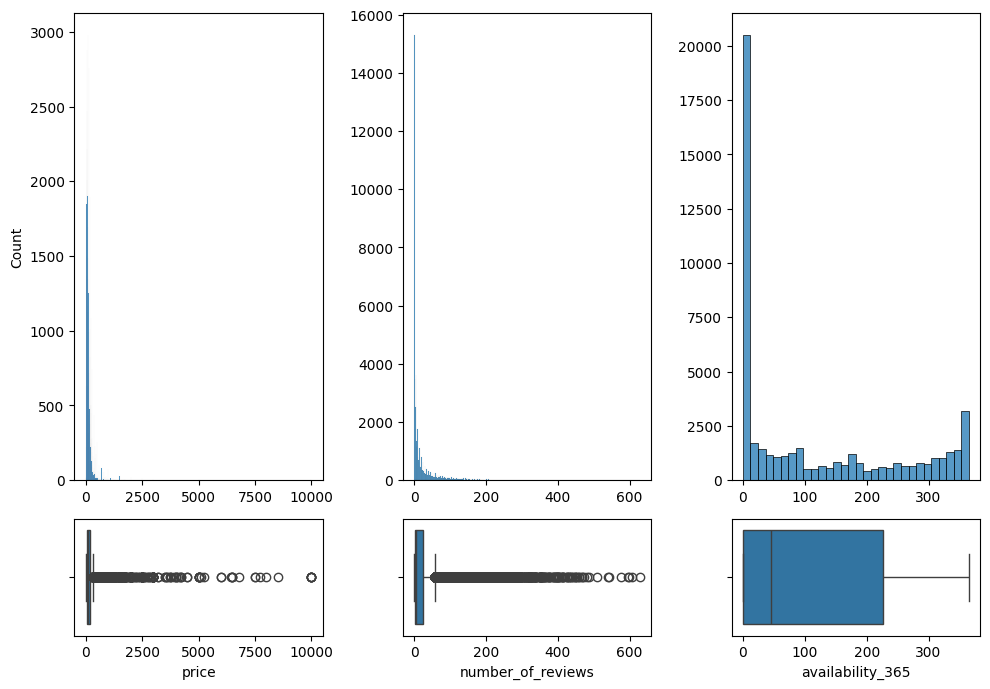

In [59]:
fig, axis = plt.subplots(2, 3, figsize = (10, 7), gridspec_kw={'height_ratios': [4, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_data, x = "price").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_data, x = "price")
sns.histplot(ax = axis[0, 1], data = total_data, x = "number_of_reviews").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "number_of_reviews").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = total_data, x = "availability_365").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = total_data, x = "availability_365").set(ylabel = None)
#sns.histplot(ax = axis[1, 2], data = total_data, x = "number_of_reviews").set(xlabel = None, ylabel = None)
#sns.boxplot(ax = axis[1, 1], data = total_data, x = "number_of_reviews").set(ylabel = None)
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()